# NLP Project - Insurance Reviews Analysis

This notebook implements the full pipeline for analyzing insurance reviews:
1. Data exploration and cleaning
2. Topic modeling (LDA)
3. Word embeddings (Word2Vec, GloVe)
4. Supervised learning (stars, sentiment, subject prediction)
5. Results interpretation

**Dataset**: Insurance reviews from Google Drive (stars 1-5, review text, insurer)

## Phase 1: Data Loading and Exploration

In [12]:
# Imports
import os
import re
import pickle
from collections import Counter
import gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

DATA_DIR = "data"
RAW_FILE = os.path.join(DATA_DIR, "insurance_reviews.csv")
GDRIVE_URL = "https://drive.google.com/file/d/1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip/view?usp=sharing"

gdown.download(url=GDRIVE_URL, output=RAW_FILE, quiet=False, fuzzy=True)



Downloading...
From: https://drive.google.com/uc?id=1_kg5JzAzntzLI6eGM3_vmUSoeWk7f8ip
To: c:\Users\sulta\Desktop\NLP_project_no2\data\insurance_reviews.csv
100%|██████████| 12.0M/12.0M [00:01<00:00, 6.20MB/s]


'data\\insurance_reviews.csv'

In [24]:
# Charger le dataset ZIP
import zipfile
import io

def load_reviews(path):
    dfs = []
    with zipfile.ZipFile(path, "r") as z:
        for name in z.namelist():
            with z.open(name) as f:
                dfs.append(pd.read_excel(io.BytesIO(f.read()), engine="openpyxl"))
    df = pd.concat(dfs, ignore_index=True)
    return df

df = load_reviews(RAW_FILE)
df.head()

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,1.0,maitre-en-colere-114722,Pour tous les maîtres des animaux\n L'assuranc...,Eca Assurances,animaux,train,25/05/2021,01/05/2021,For all masters of animals\n ECA insurance and...,NaN,NaN
1,5.0,fredo-102557,"25 ans chez AMV pour ma moto et mes voitures, ...",AMV,moto,train,13/01/2021,01/01/2021,Loading...,NaN,NaN
2,4.0,louisonne-f-130215,Je suis satisfait de votre prestation et servi...,L'olivier Assurance,auto,train,30/08/2021,01/08/2021,Loading...,NaN,NaN
3,3.0,stephane-p-128761,SATISFAIT ET FACILE DE SOUSCRIRE UN CONTRAT EN...,AMV,moto,train,20/08/2021,01/08/2021,Loading...,NaN,NaN
4,1.0,montad-137724,Je croyais qu'allianz était une bonne assuranc...,Allianz,auto,train,18/10/2021,01/10/2021,Loading...,NaN,NaN


In [39]:
print("\nColumns:", df.columns.tolist())


Columns: ['note', 'auteur', 'avis', 'assureur', 'produit', 'type', 'date_publication', 'date_exp', 'avis_en', 'avis_cor', 'avis_cor_en', 'review_length_en', 'text_raw', 'text_cleaned', 'text_corrected']


In [54]:
# looking for the missing values
missing_counts = df.isna().sum()
missing_counts = missing_counts[missing_counts > 0]
print("columns with missing values and number of missing rows:")
print(missing_counts)


columns with missing values and number of missing rows:
note                10330
auteur                  1
avis_cor            33998
avis_cor_en         34002
review_length_en    10330
dtype: int64


In [49]:
# the 10331 missing values are from type = 'test' rows so this is not an issue here
# Missing values in the 'auteur' column is negligible
# we won't use 'avis_cor' and 'avis_cor_en'
# we just delete rows with missing 'avis_en'

df = df.dropna(subset=['avis_en'])
print("Remaining missing values in 'avis_en' ? :", df['avis_en'].isna().any())


Remaining missing values in 'avis_en' ? : False


In [50]:
# the train/test is native in the dataset given
# it represents an 70/30 split 
df_train = df[df['type']=='train']
df_test = df[df['type']=='test']
print(f"shapes of data frames (og shape is {df.shape}):\n train : {df_train.shape} \n test : {df_test.shape}")

shapes of data frames (og shape is (34433, 15)):
 train : (24103, 15) 
 test : (10330, 15)


C:\Users\sulta\AppData\Local\Temp\ipykernel_28484\983578379.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')


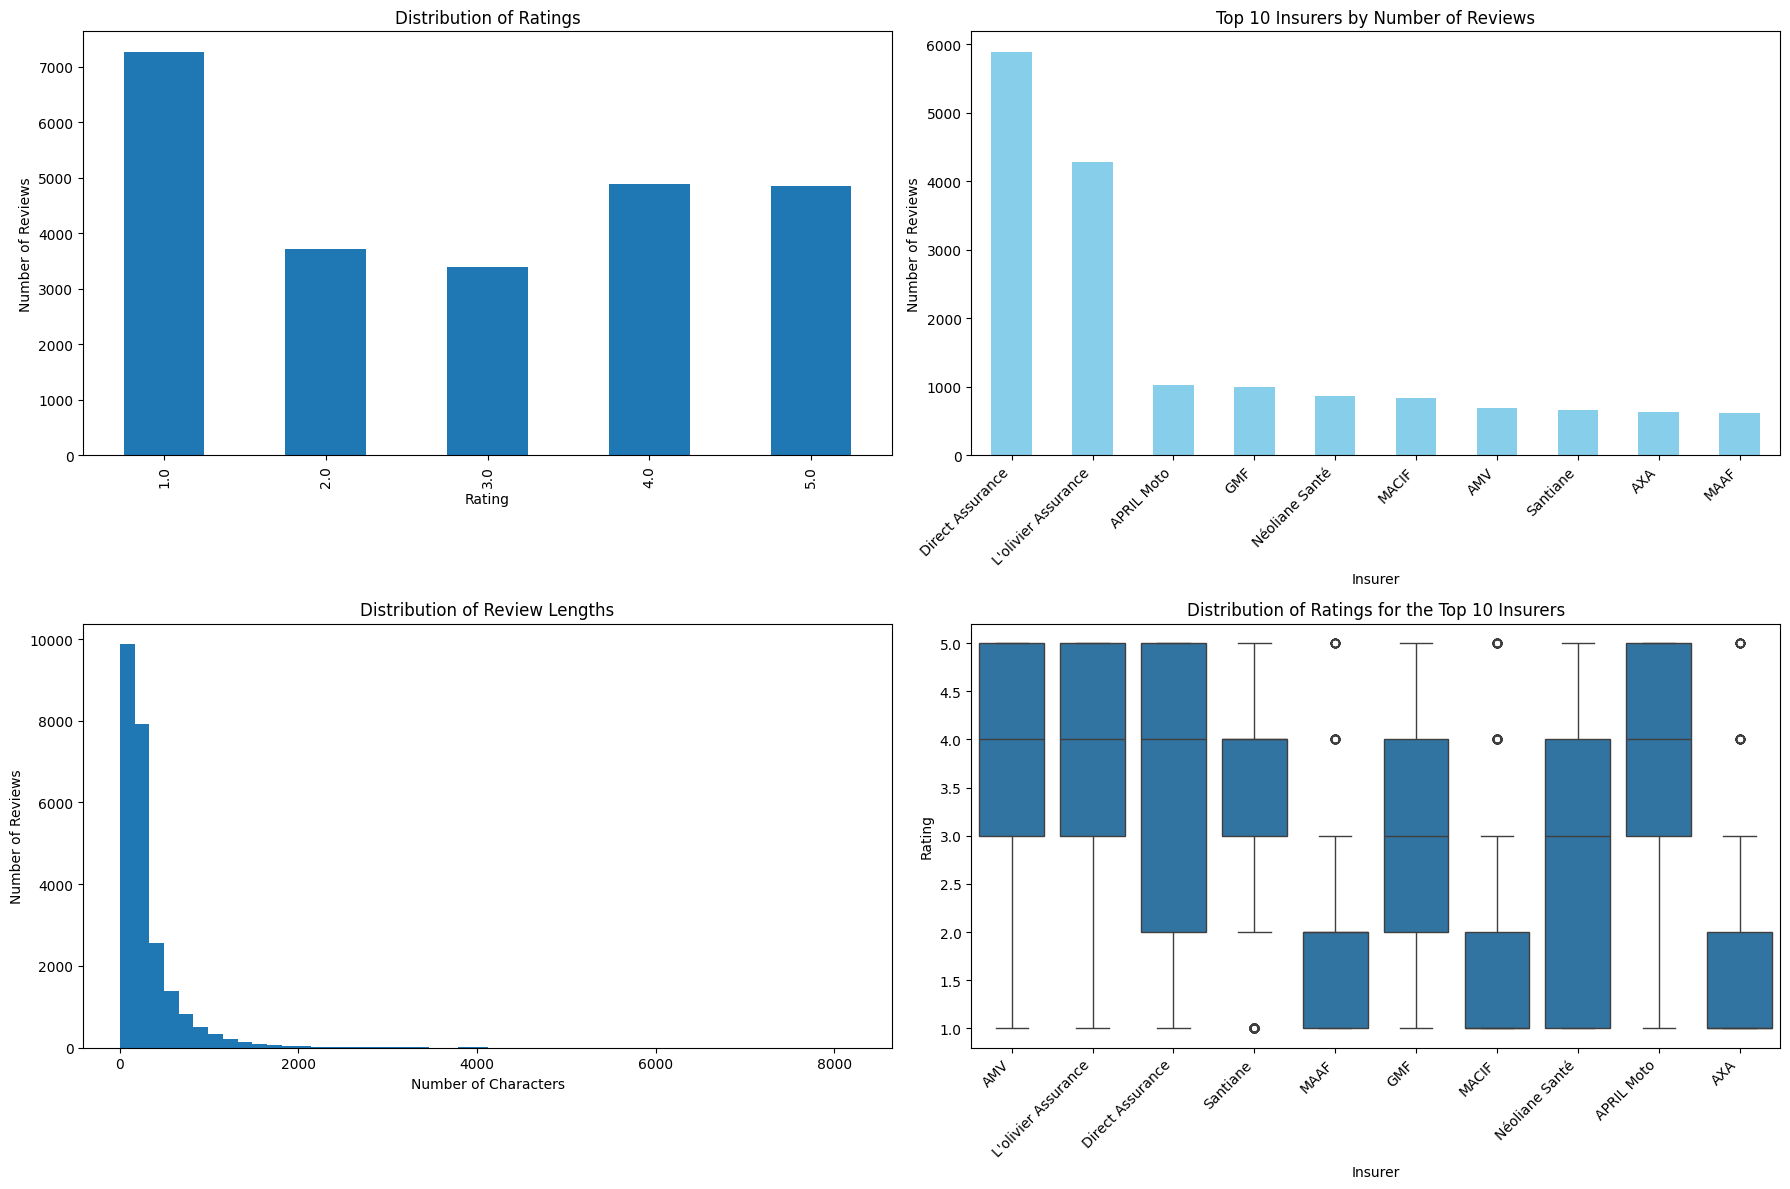

In [51]:
# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
plt.subplots_adjust(wspace=0.3, hspace=0.4)

# --- Distribution of Ratings
df_train["note"].value_counts().sort_index().plot(kind="bar", ax=axes[0, 0])
axes[0, 0].set_title("Distribution of Ratings")
axes[0, 0].set_xlabel("Rating")
axes[0, 0].set_ylabel("Number of Reviews")

# --- Top 10 Insurers by Number of Reviews
top_insurers = df_train["assureur"].value_counts().head(10)
top_insurers.plot(kind="bar", color="skyblue", ax=axes[0, 1])
axes[0, 1].set_title("Top 10 Insurers by Number of Reviews")
axes[0, 1].set_xlabel("Insurer")
axes[0, 1].set_ylabel("Number of Reviews")
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=45, ha='right')

# --- Distribution of Review Lengths
df["review_length_en"] = df_train["avis_en"].str.len()
axes[1, 0].hist(df["review_length_en"].dropna(), bins=50)
axes[1, 0].set_title("Distribution of Review Lengths")
axes[1, 0].set_xlabel("Number of Characters")
axes[1, 0].set_ylabel("Number of Reviews")

# --- Distribution of Ratings for Top 10 Insurers
sns.boxplot(
    data=df[df["assureur"].isin(top_insurers.index)],
    x="assureur",
    y="note",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Distribution of Ratings for the Top 10 Insurers")
axes[1, 1].set_xlabel("Insurer")
axes[1, 1].set_ylabel("Rating")
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

## Phase 1.2: Data Cleaning

- Frequent words and n-grams
- Spelling correction
- Clean columns: text_raw, text_cleaned, text_corrected

In [53]:
# Text preprocessing helpers
import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

STOP = set(stopwords.words("english"))

def tokenize(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = word_tokenize(text)
    return [t for t in tokens if t not in STOP and len(t) > 1]

# Keep raw text
df["text_raw"] = df["avis_en"].astype(str)